# Feature Engineering and EDA

Objective: Create meaningful operational features available before departure and explore how delay propagation risk varies under different conditions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

df = pd.read_parquet("../data/processed/flight_data_with_target.parquet")
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,delay_propagation
0,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
1,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
2,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
3,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
4,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0


In [3]:
print("delay_propagation in columns:", "delay_propagation" in df.columns)
print("LateAircraftDelay in columns:", "LateAircraftDelay" in df.columns)

delay_propagation in columns: True
LateAircraftDelay in columns: False


### 1. Departure Hour Feature

Scheduled departure time was converted into an hourly feature.
The goal is to examine how propagation risk changes throughout the day.

In [4]:
# Convert CRSDepTime to string with leading zeros
df["CRSDepTime_str"] = df["CRSDepTime"].astype(int).astype(str).str.zfill(4)

# Extract hour
df["departure_hour"] = df["CRSDepTime_str"].str[:2].astype(int)

df[["CRSDepTime", "departure_hour"]].head()   

,CRSDepTime,departure_hour
0,1738,17
1,815,8
2,1540,15
3,630,6
4,1300,13


In [5]:
df["departure_hour"].describe()
df["departure_hour"].value_counts().sort_index()

departure_hour
0       736
1       332
2       124
3       125
4        58
5     14733
6     40050
7     37818
8     37248
9     32669
10    35807
11    35307
12    34771
13    34871
14    34376
15    32773
16    33141
17    34992
18    35296
19    28784
20    23215
21    17300
22    10306
23     3883
Name: count, dtype: int64

In [6]:
prop_by_hour = (
    df.groupby("departure_hour")["delay_propagation"]
    .mean()
    .reset_index()
)

prop_by_hour.head()

,departure_hour,delay_propagation
0,0,0.115489
1,1,0.132530
2,2,0.185484
3,3,0.200000
4,4,0.086207


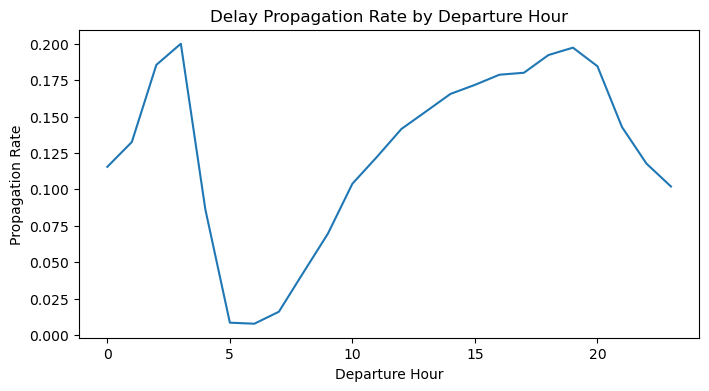

In [7]:
plt.figure(figsize=(8,4))
plt.plot(prop_by_hour["departure_hour"], prop_by_hour["delay_propagation"])
plt.xlabel("Departure Hour")
plt.ylabel("Propagation Rate")
plt.title("Delay Propagation Rate by Departure Hour")
plt.show()

### 2. Day of Week Analysis

Delay propagation is analyzed across weekdays to check if weekly schedule patterns influence delay spread.

In [8]:
df["DayOfWeek"].value_counts().sort_index()

DayOfWeek
1    91698
2    85758
3    88722
4    76498
5    75122
6    65432
7    75485
Name: count, dtype: int64

In [9]:
prop_by_day = (
    df.groupby("DayOfWeek")["delay_propagation"]
    .mean()
    .reset_index()
)

prop_by_day

,DayOfWeek,delay_propagation
0,1,0.128367
1,2,0.144430
2,3,0.091860
3,4,0.091963
4,5,0.142568
5,6,0.119345
6,7,0.131311


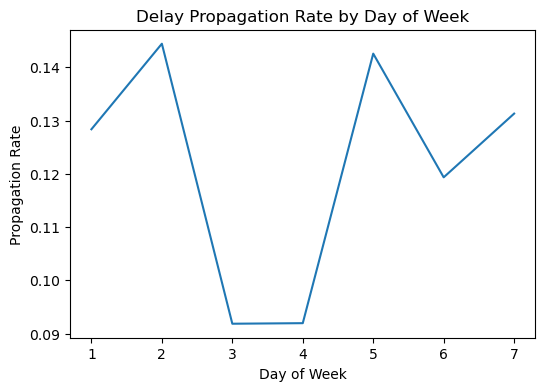

In [10]:
plt.figure(figsize=(6,4))
plt.plot(prop_by_day["DayOfWeek"], prop_by_day["delay_propagation"])
plt.xlabel("Day of Week")
plt.ylabel("Propagation Rate")
plt.title("Delay Propagation Rate by Day of Week")
plt.show()

### 3. Route Distance (DistanceGroup)

DistanceGroup is used as a proxy for route type to examine whether short, mid, or long-haul flights differ in propagation risk.

In [11]:
df["Distance"].describe()

count    558715.000000
mean        806.676008
std         585.709113
min          31.000000
25%         376.000000
50%         659.000000
75%        1050.000000
max        5095.000000
Name: Distance, dtype: float64

In [12]:
df["DistanceGroup"].value_counts().sort_index()

DistanceGroup
1      72079
2     129871
3     108981
4      90379
5      67467
6      24821
7      23436
8      10688
9       8495
10     12264
11     10234
Name: count, dtype: int64

In [13]:
prop_by_distance = (
    df.groupby("DistanceGroup")["delay_propagation"]
    .mean()
    .reset_index()
)

prop_by_distance

,DistanceGroup,delay_propagation
0,1,0.120326
1,2,0.119472
2,3,0.121663
3,4,0.130650
4,5,0.136645
5,6,0.116555
6,7,0.116189
7,8,0.101235
8,9,0.088758
9,10,0.078033


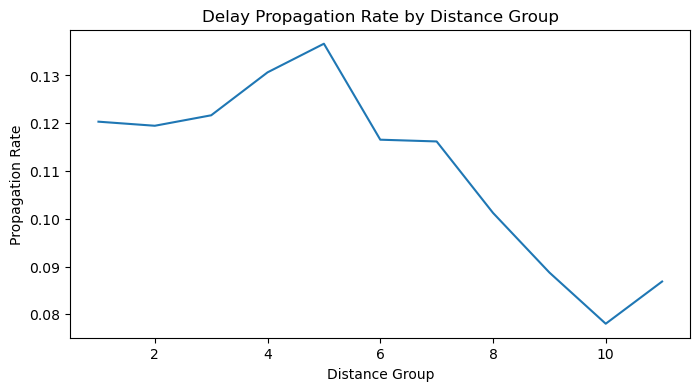

In [14]:
plt.figure(figsize=(8,4))
plt.plot(prop_by_distance["DistanceGroup"], prop_by_distance["delay_propagation"])
plt.xlabel("Distance Group")
plt.ylabel("Propagation Rate")
plt.title("Delay Propagation Rate by Distance Group")
plt.show()

### 4. Airport Congestion Proxy

Airport congestion is approximated using the number of departures from the same airport within the same hour.

In [15]:
# Count number of departures per airport per hour
airport_hour_traffic = (
    df.groupby(["Origin", "departure_hour"])
      .size()
      .reset_index(name="airport_hour_flights")
)

airport_hour_traffic.head()

,Origin,departure_hour,airport_hour_flights
0,ABE,6,92
1,ABE,7,16
2,ABE,8,20
3,ABE,9,10
4,ABE,10,13


In [16]:
df = df.merge(
    airport_hour_traffic,
    on=["Origin", "departure_hour"],
    how="left"
)

df[["Origin", "departure_hour", "airport_hour_flights"]].head()

,Origin,departure_hour,airport_hour_flights
0,MHT,17,75
1,IAD,8,1162
2,EWR,15,710
3,STL,6,468
4,STL,13,314


In [17]:
df["airport_hour_flights"].describe()

count    558715.000000
mean        679.883484
std         600.944748
min           1.000000
25%         198.000000
50%         515.000000
75%         973.000000
max        2487.000000
Name: airport_hour_flights, dtype: float64

In [18]:
# Create congestion bins
df["congestion_level"] = pd.qcut(
    df["airport_hour_flights"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df["congestion_level"].value_counts()


congestion_level
Low          140269
High         139752
Very High    139471
Medium       139223
Name: count, dtype: int64

In [19]:
prop_by_congestion = (
    df.groupby("congestion_level")["delay_propagation"]
    .mean()
    .reset_index()
)

prop_by_congestion

C:\Users\Abdul Basit\AppData\Local\Temp\ipykernel_11360\2937277602.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("congestion_level")["delay_propagation"]


,congestion_level,delay_propagation
0,Low,0.121082
1,Medium,0.123816
2,High,0.119920
3,Very High,0.120398


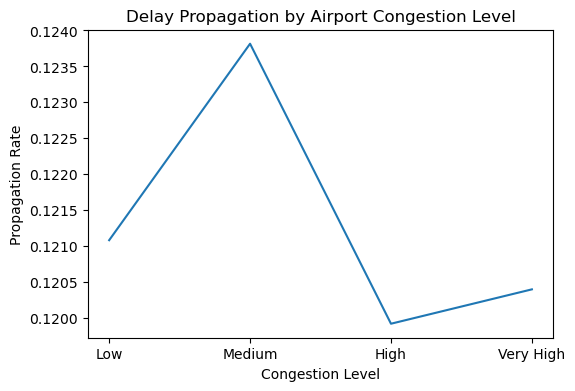

In [20]:
plt.figure(figsize=(6,4))
plt.plot(prop_by_congestion["congestion_level"],
         prop_by_congestion["delay_propagation"])
plt.xlabel("Congestion Level")
plt.ylabel("Propagation Rate")
plt.title("Delay Propagation by Airport Congestion Level")
plt.show()

### 5. Aircraft Rotation Feature

Previous arrival delay of the same aircraft is calculated to capture delay carryover effects.

In [21]:
# Ensure correct sorting for rotation logic
df = df.sort_values(by=["Tail_Number", "FlightDate", "CRSDepTime"])

In [22]:
df["previous_arrival_delay"] = (
    df.groupby(["Tail_Number", "FlightDate"])["ArrDelay"]
      .shift(1)
)

In [23]:
df[["Tail_Number", "FlightDate", "CRSDepTime", "ArrDelay", "previous_arrival_delay"]].head(15)


,Tail_Number,FlightDate,CRSDepTime,ArrDelay,previous_arrival_delay
239868,188NV,2024-01-28,1718,346.0,NaN
238738,190NV,2024-01-01,1230,-16.0,NaN
235804,190NV,2024-01-01,1520,-8.0,-16.0
236424,190NV,2024-01-01,1811,26.0,-8.0
235925,190NV,2024-01-01,2043,14.0,26.0
233435,190NV,2024-01-02,600,-24.0,NaN
232393,190NV,2024-01-02,831,13.0,-24.0
233747,190NV,2024-01-02,1407,16.0,13.0
239136,190NV,2024-01-02,1704,6.0,16.0
239217,190NV,2024-01-03,600,1.0,NaN


In [24]:
df["previous_arrival_delay"].isnull().sum()

146823

In [25]:
# Create simple bins for previous delay
df["prev_delay_bin"] = pd.cut(
    df["previous_arrival_delay"],
    bins=[-999, 0, 15, 60, 3000],
    labels=["No Delay", "Small (0-15)", "Medium (15-60)", "Large (60+)"]
)

prop_by_prev_delay = (
    df.groupby("prev_delay_bin")["delay_propagation"]
      .mean()
      .reset_index()
)

prop_by_prev_delay

C:\Users\Abdul Basit\AppData\Local\Temp\ipykernel_11360\3226149264.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("prev_delay_bin")["delay_propagation"]


,prev_delay_bin,delay_propagation
0,No Delay,0.024439
1,Small (0-15),0.124612
2,Medium (15-60),0.473242
3,Large (60+),0.709104


In [ ]:
# Create indicator for first flight of the day
df["is_first_flight_of_day"] = df["previous_arrival_delay"].isnull().astype(int)

# Fill null previous delay with 0
df["previous_arrival_delay"] = df["previous_arrival_delay"].fillna(0)

In [27]:
df[["previous_arrival_delay", "is_first_flight_of_day"]].head()

,previous_arrival_delay,is_first_flight_of_day
239868,0.0,1
238738,0.0,1
235804,-16.0,0
236424,-8.0,0
235925,26.0,0


In [28]:
df["previous_delay_positive"] = (df["previous_arrival_delay"] > 0).astype(int)

In [30]:
df_model.isnull().sum()

departure_hour             0
DayOfWeek                  0
DistanceGroup              0
airport_hour_flights       0
previous_arrival_delay     0
previous_delay_positive    0
is_first_flight_of_day     0
delay_propagation          0
dtype: int64

In [31]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 558715 entries, 239868 to 144219
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   departure_hour           558715 non-null  int32  
 1   DayOfWeek                558715 non-null  int64  
 2   DistanceGroup            558715 non-null  int64  
 3   airport_hour_flights     558715 non-null  int64  
 4   previous_arrival_delay   558715 non-null  float64
 5   previous_delay_positive  558715 non-null  int32  
 6   is_first_flight_of_day   558715 non-null  int32  
 7   delay_propagation        558715 non-null  int32  
dtypes: float64(1), int32(4), int64(3)
memory usage: 29.8 MB


In [ ]:
# df_model = df_model.reset_index(drop=True)

In [ ]:
# df_model.to_parquet(
#     "../data/processed/flight_data_model_ready.parquet",
#     index=False
# )

# Feature Engineering and EDA

Objective: Create meaningful operational features available before departure and explore how delay propagation risk varies under different conditions.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

df = pd.read_parquet("../data/processed/flight_data_with_target.parquet")
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,delay_propagation
0,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
1,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
2,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
3,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
4,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0


In [ ]:
print("delay_propagation in columns:", "delay_propagation" in df.columns)
print("LateAircraftDelay in columns:", "LateAircraftDelay" in df.columns)

delay_propagation in columns: True
LateAircraftDelay in columns: False


### 1. Departure Hour Feature

Scheduled departure time was converted into an hourly feature.
The goal is to examine how propagation risk changes throughout the day.

In [ ]:
# Convert CRSDepTime to string with leading zeros
df["CRSDepTime_str"] = df["CRSDepTime"].astype(int).astype(str).str.zfill(4)

# Extract hour
df["departure_hour"] = df["CRSDepTime_str"].str[:2].astype(int)

df[["CRSDepTime", "departure_hour"]].head()   

,CRSDepTime,departure_hour
0,1738,17
1,815,8
2,1540,15
3,630,6
4,1300,13


In [ ]:
df["departure_hour"].describe()
df["departure_hour"].value_counts().sort_index()

departure_hour
0       736
1       332
2       124
3       125
4        58
5     14733
6     40050
7     37818
8     37248
9     32669
10    35807
11    35307
12    34771
13    34871
14    34376
15    32773
16    33141
17    34992
18    35296
19    28784
20    23215
21    17300
22    10306
23     3883
Name: count, dtype: int64

In [ ]:
prop_by_hour = (
    df.groupby("departure_hour")["delay_propagation"]
    .mean()
    .reset_index()
)

prop_by_hour.head()

,departure_hour,delay_propagation
0,0,0.115489
1,1,0.132530
2,2,0.185484
3,3,0.200000
4,4,0.086207


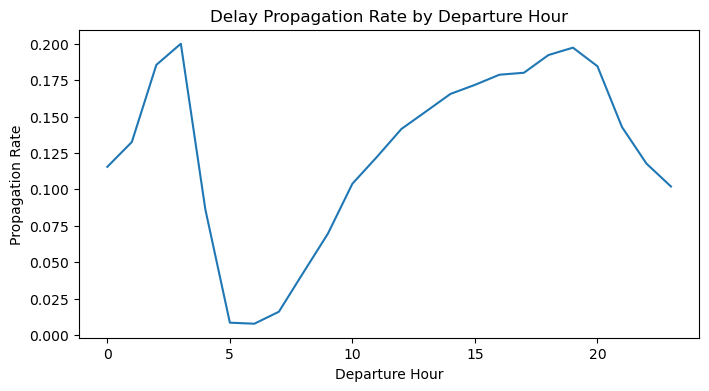

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(prop_by_hour["departure_hour"], prop_by_hour["delay_propagation"])
plt.xlabel("Departure Hour")
plt.ylabel("Propagation Rate")
plt.title("Delay Propagation Rate by Departure Hour")
plt.show()

### 2. Day of Week Analysis

Delay propagation is analyzed across weekdays to check if weekly schedule patterns influence delay spread.

In [ ]:
df["DayOfWeek"].value_counts().sort_index()

DayOfWeek
1    91698
2    85758
3    88722
4    76498
5    75122
6    65432
7    75485
Name: count, dtype: int64

In [ ]:
prop_by_day = (
    df.groupby("DayOfWeek")["delay_propagation"]
    .mean()
    .reset_index()
)

prop_by_day

,DayOfWeek,delay_propagation
0,1,0.128367
1,2,0.144430
2,3,0.091860
3,4,0.091963
4,5,0.142568
5,6,0.119345
6,7,0.131311


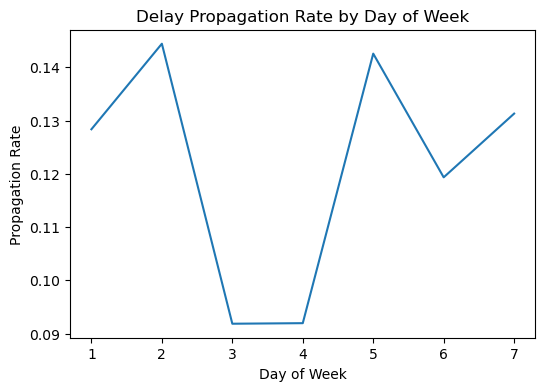

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(prop_by_day["DayOfWeek"], prop_by_day["delay_propagation"])
plt.xlabel("Day of Week")
plt.ylabel("Propagation Rate")
plt.title("Delay Propagation Rate by Day of Week")
plt.show()

### 3. Route Distance (DistanceGroup)

DistanceGroup is used as a proxy for route type to examine whether short, mid, or long-haul flights differ in propagation risk.

In [ ]:
df["Distance"].describe()

count    558715.000000
mean        806.676008
std         585.709113
min          31.000000
25%         376.000000
50%         659.000000
75%        1050.000000
max        5095.000000
Name: Distance, dtype: float64

In [ ]:
df["DistanceGroup"].value_counts().sort_index()

DistanceGroup
1      72079
2     129871
3     108981
4      90379
5      67467
6      24821
7      23436
8      10688
9       8495
10     12264
11     10234
Name: count, dtype: int64

In [ ]:
prop_by_distance = (
    df.groupby("DistanceGroup")["delay_propagation"]
    .mean()
    .reset_index()
)

prop_by_distance

,DistanceGroup,delay_propagation
0,1,0.120326
1,2,0.119472
2,3,0.121663
3,4,0.130650
4,5,0.136645
5,6,0.116555
6,7,0.116189
7,8,0.101235
8,9,0.088758
9,10,0.078033


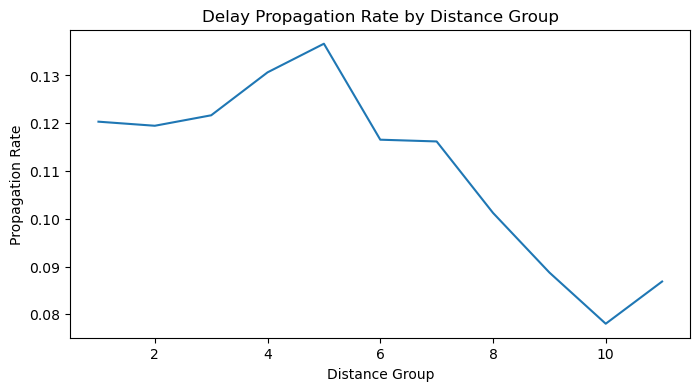

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(prop_by_distance["DistanceGroup"], prop_by_distance["delay_propagation"])
plt.xlabel("Distance Group")
plt.ylabel("Propagation Rate")
plt.title("Delay Propagation Rate by Distance Group")
plt.show()

### 4. Airport Congestion Proxy

Airport congestion is approximated using the number of departures from the same airport within the same hour.

In [ ]:
# Count number of departures per airport per hour
airport_hour_traffic = (
    df.groupby(["Origin", "departure_hour"])
      .size()
      .reset_index(name="airport_hour_flights")
)

airport_hour_traffic.head()

,Origin,departure_hour,airport_hour_flights
0,ABE,6,92
1,ABE,7,16
2,ABE,8,20
3,ABE,9,10
4,ABE,10,13


In [ ]:
df = df.merge(
    airport_hour_traffic,
    on=["Origin", "departure_hour"],
    how="left"
)

df[["Origin", "departure_hour", "airport_hour_flights"]].head()

,Origin,departure_hour,airport_hour_flights
0,MHT,17,75
1,IAD,8,1162
2,EWR,15,710
3,STL,6,468
4,STL,13,314


In [ ]:
df["airport_hour_flights"].describe()

count    558715.000000
mean        679.883484
std         600.944748
min           1.000000
25%         198.000000
50%         515.000000
75%         973.000000
max        2487.000000
Name: airport_hour_flights, dtype: float64

In [ ]:
# Create congestion bins
df["congestion_level"] = pd.qcut(
    df["airport_hour_flights"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df["congestion_level"].value_counts()


congestion_level
Low          140269
High         139752
Very High    139471
Medium       139223
Name: count, dtype: int64

In [ ]:
prop_by_congestion = (
    df.groupby("congestion_level")["delay_propagation"]
    .mean()
    .reset_index()
)

prop_by_congestion

C:\Users\Abdul Basit\AppData\Local\Temp\ipykernel_11360\2937277602.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("congestion_level")["delay_propagation"]


,congestion_level,delay_propagation
0,Low,0.121082
1,Medium,0.123816
2,High,0.119920
3,Very High,0.120398


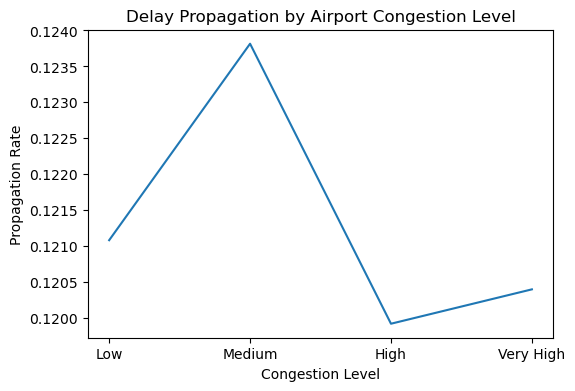

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(prop_by_congestion["congestion_level"],
         prop_by_congestion["delay_propagation"])
plt.xlabel("Congestion Level")
plt.ylabel("Propagation Rate")
plt.title("Delay Propagation by Airport Congestion Level")
plt.show()

### 5. Aircraft Rotation Feature

Previous arrival delay of the same aircraft is calculated to capture delay carryover effects.

In [ ]:
# Ensure correct sorting for rotation logic
df = df.sort_values(by=["Tail_Number", "FlightDate", "CRSDepTime"])

In [ ]:
df["previous_arrival_delay"] = (
    df.groupby(["Tail_Number", "FlightDate"])["ArrDelay"]
      .shift(1)
)

In [ ]:
df[["Tail_Number", "FlightDate", "CRSDepTime", "ArrDelay", "previous_arrival_delay"]].head(15)


,Tail_Number,FlightDate,CRSDepTime,ArrDelay,previous_arrival_delay
239868,188NV,2024-01-28,1718,346.0,NaN
238738,190NV,2024-01-01,1230,-16.0,NaN
235804,190NV,2024-01-01,1520,-8.0,-16.0
236424,190NV,2024-01-01,1811,26.0,-8.0
235925,190NV,2024-01-01,2043,14.0,26.0
233435,190NV,2024-01-02,600,-24.0,NaN
232393,190NV,2024-01-02,831,13.0,-24.0
233747,190NV,2024-01-02,1407,16.0,13.0
239136,190NV,2024-01-02,1704,6.0,16.0
239217,190NV,2024-01-03,600,1.0,NaN


In [ ]:
df["previous_arrival_delay"].isnull().sum()

146823

In [ ]:
# Create simple bins for previous delay
df["prev_delay_bin"] = pd.cut(
    df["previous_arrival_delay"],
    bins=[-999, 0, 15, 60, 3000],
    labels=["No Delay", "Small (0-15)", "Medium (15-60)", "Large (60+)"]
)

prop_by_prev_delay = (
    df.groupby("prev_delay_bin")["delay_propagation"]
      .mean()
      .reset_index()
)

prop_by_prev_delay

C:\Users\Abdul Basit\AppData\Local\Temp\ipykernel_11360\3226149264.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("prev_delay_bin")["delay_propagation"]


,prev_delay_bin,delay_propagation
0,No Delay,0.024439
1,Small (0-15),0.124612
2,Medium (15-60),0.473242
3,Large (60+),0.709104


In [ ]:
# Create indicator for first flight of the day
df["is_first_flight_of_day"] = df["previous_arrival_delay"].isnull().astype(int)

# Fill null previous delay with 0
df["previous_arrival_delay"] = df["previous_arrival_delay"].fillna(0)

In [ ]:
df[["previous_arrival_delay", "is_first_flight_of_day"]].head()

,previous_arrival_delay,is_first_flight_of_day
239868,0.0,1
238738,0.0,1
235804,-16.0,0
236424,-8.0,0
235925,26.0,0


In [ ]:
df["previous_delay_positive"] = (df["previous_arrival_delay"] > 0).astype(int)

In [ ]:
### 6. Final Feature Selection and Dataset Preparation

# Only relevant, non-leaking features are retained for modeling.
# model_columns = [
#     "departure_hour",
#     "DayOfWeek",
#     "DistanceGroup",
#     "airport_hour_flights",
#     "previous_arrival_delay",
#     "previous_delay_positive",
#     "is_first_flight_of_day",
#     "delay_propagation"
# ]

# df_model = df[model_columns].copy()

# df_model.head()

In [ ]:
df_model.isnull().sum()

departure_hour             0
DayOfWeek                  0
DistanceGroup              0
airport_hour_flights       0
previous_arrival_delay     0
previous_delay_positive    0
is_first_flight_of_day     0
delay_propagation          0
dtype: int64

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 558715 entries, 239868 to 144219
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   departure_hour           558715 non-null  int32  
 1   DayOfWeek                558715 non-null  int64  
 2   DistanceGroup            558715 non-null  int64  
 3   airport_hour_flights     558715 non-null  int64  
 4   previous_arrival_delay   558715 non-null  float64
 5   previous_delay_positive  558715 non-null  int32  
 6   is_first_flight_of_day   558715 non-null  int32  
 7   delay_propagation        558715 non-null  int32  
dtypes: float64(1), int32(4), int64(3)
memory usage: 29.8 MB


In [ ]:
# df_model = df_model.reset_index(drop=True)

In [ ]:
# df_model.to_parquet(
#     "../data/processed/flight_data_model_ready.parquet",
#     index=False
# )

## Insights from Initial Feature Engineering

### 1. Goal of This Stage

This stage focused on defining the target variable and building meaningful operational features using information available before departure.

The aim was to understand how delay propagation behaves under different conditions and identify which factors seem most influential.

---

### 2. Target Definition – Delay Propagation

The column `LateAircraftDelay` represents the number of minutes a flight was delayed because the same aircraft arrived late from a previous leg.

After examining its distribution, delay propagation was defined as:

- `1` if `LateAircraftDelay > 0`
- `0` otherwise

This created a binary target variable called `delay_propagation`.

The original `LateAircraftDelay` column was removed to prevent data leakage during modeling.

---

### 3. Main Observations from Feature Exploration

All features were built using pre-departure information.

**Departure Hour**
- Propagation risk was very low early in the morning.
- Risk increased steadily throughout the day.
- Evening flights had the highest propagation rates.

This suggests delays accumulate as aircraft operate multiple rotations.

**Day of Week**
- Some variation across weekdays.
- Differences were small compared to time-of-day effects.

**Distance Group**
- Mid-haul routes showed slightly higher propagation.
- Very long-haul routes showed lower risk.

**Airport Congestion**
- The congestion proxy (departures per airport per hour) did not show a strong relationship.
- Aircraft-level effects appeared more important than airport-level traffic.

**Aircraft Rotation (Strongest Signal)**
- Previous arrival delay of the same aircraft had a clear impact.
- Larger previous delays led to significantly higher propagation risk.

This supports the idea that delay propagation is mainly driven by aircraft rotation effects.

---

### 4. Limitations

- Aircraft sequence was approximated using scheduled order.
- Real-time congestion, weather dynamics, crew limits, and turnaround buffers are not included.
- The congestion proxy reflects structural traffic rather than real-time operational stress.

These features capture structural operational patterns, but not full real-world complexity.

## Feature Refinement and Improvement

In this section, additional operational features are added to improve model performance.
Some weaker features are removed based on previous importance results.

In [ ]:
import pandas as pd

df = pd.read_parquet("../data/processed/flight_data_with_target.parquet")

df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,delay_propagation
0,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
1,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
2,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
3,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0
4,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,0


In [ ]:
# Add departure delay features
df["departure_delay"] = df["DepDelay"].fillna(0)

df["departure_delay_15plus"] = (df["departure_delay"] >= 15).astype(int)

In [ ]:
# Sort properly
df = df.sort_values(by=["Tail_Number", "FlightDate", "CRSDepTime"])

# Previous arrival delay across flights (no day reset)
df["previous_arrival_delay"] = (
    df.groupby("Tail_Number")["ArrDelay"]
      .shift(1)
)

df["previous_arrival_delay"] = df["previous_arrival_delay"].fillna(0)

df["previous_delay_positive"] = (df["previous_arrival_delay"] > 0).astype(int)

In [ ]:
df["CRSDepTime_str"] = df["CRSDepTime"].astype(int).astype(str).str.zfill(4)
df["departure_hour"] = df["CRSDepTime_str"].str[:2].astype(int)

In [ ]:
airport_hour_traffic = (
    df.groupby(["Origin", "departure_hour"])
      .size()
      .reset_index(name="airport_hour_flights")
)

df = df.merge(
    airport_hour_traffic,
    on=["Origin", "departure_hour"],
    how="left"
)

In [ ]:
model_columns = [
    "departure_hour",
    "DayOfWeek",
    "DistanceGroup",
    "airport_hour_flights",
    "previous_arrival_delay",
    "previous_delay_positive",
    "departure_delay",
    "departure_delay_15plus",
    "delay_propagation"
]

df_model = df[model_columns].copy()

df_model = df_model.reset_index(drop=True)

In [ ]:

df_model.info()

## Feature Refinement and Improvement

In this section, additional operational features are added to improve model performance.
Some weaker features are removed based on previous importance results.

In [1]:
import pandas as pd
# FINAL FEATURE CONSTRUCTION

# Reload clean dataset with target
df = pd.read_parquet("../data/processed/flight_data_with_target.parquet")


In [2]:

# 1. Departure Hour
df["CRSDepTime_str"] = df["CRSDepTime"].astype(int).astype(str).str.zfill(4)
df["departure_hour"] = df["CRSDepTime_str"].str[:2].astype(int)

In [3]:
# 2. Departure Delay Features

df["departure_delay"] = df["DepDelay"].fillna(0)
df["departure_delay_15plus"] = (df["departure_delay"] >= 15).astype(int)

In [4]:
# 3. Airport Congestion Feature

airport_hour_traffic = (
    df.groupby(["Origin", "departure_hour"])
      .size()
      .reset_index(name="airport_hour_flights")
)

df = df.merge(
    airport_hour_traffic,
    on=["Origin", "departure_hour"],
    how="left"
)

In [5]:
# 4. Aircraft Rotation Feature (Improved)

df = df.sort_values(by=["Tail_Number", "FlightDate", "CRSDepTime"])

df["previous_arrival_delay"] = (
    df.groupby("Tail_Number")["ArrDelay"]
      .shift(1)
)

df["previous_arrival_delay"] = df["previous_arrival_delay"].fillna(0)

df["previous_delay_positive"] = (df["previous_arrival_delay"] > 0).astype(int)

In [6]:
# 5. Final Feature Selection

model_columns = [
    "departure_hour",
    "DayOfWeek",
    "DistanceGroup",
    "airport_hour_flights",
    "previous_arrival_delay",
    "previous_delay_positive",
    "departure_delay",
    "departure_delay_15plus",
    "delay_propagation"
]

df_model = df[model_columns].copy()
df_model = df_model.reset_index(drop=True)


In [7]:
df_model.isnull().sum()

departure_hour             0
DayOfWeek                  0
DistanceGroup              0
airport_hour_flights       0
previous_arrival_delay     0
previous_delay_positive    0
departure_delay            0
departure_delay_15plus     0
delay_propagation          0
dtype: int64

In [8]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558715 entries, 0 to 558714
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   departure_hour           558715 non-null  int32  
 1   DayOfWeek                558715 non-null  int64  
 2   DistanceGroup            558715 non-null  int64  
 3   airport_hour_flights     558715 non-null  int64  
 4   previous_arrival_delay   558715 non-null  float64
 5   previous_delay_positive  558715 non-null  int32  
 6   departure_delay          558715 non-null  float64
 7   departure_delay_15plus   558715 non-null  int32  
 8   delay_propagation        558715 non-null  int32  
dtypes: float64(2), int32(4), int64(3)
memory usage: 29.8 MB


In [9]:
# 7. Save Final Model Dataset

df_model.to_parquet(
    "../data/processed/flight_data_model_ready_v2.parquet",
    index=False
)

print("\nFinal model dataset saved successfully.")


Final model dataset saved successfully.


## Feature Refinement and Improvement

After reviewing the initial modeling results, the feature set was improved to better capture operational disruption patterns.

---

### 1. Improved Aircraft Rotation Logic

Previously, previous arrival delay was calculated within the same day.  
This was updated to track aircraft rotation continuously using `Tail_Number` without resetting at midnight.

This better reflects real aircraft operations and improves modeling of delay carryover.

---

### 2. Added Departure Delay Features

Two additional features were introduced:

- `departure_delay` (actual departure delay in minutes)
- `departure_delay_15plus` (indicator for 15+ minute delay)

Departure delay is an important operational signal and helps capture immediate disruption effects.

---

### 3. Clean Rebuilding of Features

All final features were rebuilt in a single independent block to ensure:

- No dependency on earlier EDA cells
- Reproducibility
- Clear modeling pipeline

---

### 4. Final Modeling Feature Set

The final model-ready dataset includes:

- departure_hour  
- DayOfWeek  
- DistanceGroup  
- airport_hour_flights  
- previous_arrival_delay  
- previous_delay_positive  
- departure_delay  
- departure_delay_15plus  
- delay_propagation (target)

Only operational context available before or at departure was retained.

The dataset is now fully prepared for improved modeling and evaluation.